In [ ]:
import os

print(os.listdir('/content'))

['.config', 'order.xlsx', 'sample_data']


# Olist E-Commerce Data Analysis

### Exploratory Data Analysis, Customer Satisfaction & Marketplace Performance

**Objective:**
To analyze Olist marketplace performance, customer satisfaction, delivery performance, seller and product patterns, and payment behavior using data analysis and visualization.


In [ ]:
import pandas as pd

df = pd.read_excel('/content/order.xlsx')

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
excel_file = pd.ExcelFile('/content/order.xlsx')
print(excel_file.sheet_names)

['orders', 'order_items', 'order_payments', 'order_reviews', 'customers', 'products', 'sellers', 'geolocation', 'category_translation']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/order.xlsx'

orders = pd.read_excel(file_path, sheet_name='orders')
items = pd.read_excel(file_path, sheet_name='order_items')
payments = pd.read_excel(file_path, sheet_name='order_payments')
reviews = pd.read_excel(file_path, sheet_name='order_reviews')
customers = pd.read_excel(file_path, sheet_name='customers')
products = pd.read_excel(file_path, sheet_name='products')
sellers = pd.read_excel(file_path, sheet_name='sellers')
geolocation = pd.read_excel(file_path, sheet_name='geolocation')
translation = pd.read_excel(file_path, sheet_name='category_translation')

print("All sheets loaded successfully!")

All sheets loaded successfully!


In [ ]:
print("Orders       :", orders.shape)
print("Items        :", items.shape)
print("Payments     :", payments.shape)
print("Reviews      :", reviews.shape)
print("Customers    :", customers.shape)
print("Products     :", products.shape)
print("Sellers      :", sellers.shape)
print("Geolocation  :", geolocation.shape)
print("Translation  :", translation.shape)

Orders       : (99441, 8)
Items        : (112650, 6)
Payments     : (103886, 5)
Reviews      : (100000, 7)
Customers    : (99441, 5)
Products     : (32951, 9)
Sellers      : (3095, 4)
Geolocation  : (1000163, 5)
Translation  : (71, 2)


In [ ]:
print("ORDERS:")
print(orders.columns.tolist())

print("\nITEMS:")
print(items.columns.tolist())

print("\nPAYMENTS:")
print(payments.columns.tolist())

print("\nREVIEWS:")
print(reviews.columns.tolist())

print("\nCUSTOMERS:")
print(customers.columns.tolist())

print("\nPRODUCTS:")
print(products.columns.tolist())

print("\nSELLERS:")
print(sellers.columns.tolist())

print("\nGEOLOCATION:")
print(geolocation.columns.tolist())

print("\nTRANSLATION:")
print(translation.columns.tolist())

ORDERS:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ITEMS:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value']

PAYMENTS:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

REVIEWS:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

CUSTOMERS:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

PRODUCTS:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

GEOLOCATION:
['geolocation_zip_code_prefix', 'geolo

In [ ]:
display(orders.head())
display(items.head())
display(payments.head())
display(reviews.head())
display(customers.head())
display(products.head())
display(sellers.head())
display(geolocation.head())
display(translation.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:

dataframes = {
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'translation': translation
}

for name, data in dataframes.items():
    unnamed_cols = [col for col in data.columns if str(col).startswith('Unnamed')]

    if unnamed_cols:
        data.drop(columns=unnamed_cols, inplace=True)
        print(f"{name}: Removed {unnamed_cols}")

In [ ]:
for name, data in dataframes.items():
    print(f"{name}: {data.duplicated().sum()} duplicate rows")

orders: 0 duplicate rows
items: 0 duplicate rows
payments: 0 duplicate rows
reviews: 0 duplicate rows
customers: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
geolocation: 261831 duplicate rows
translation: 0 duplicate rows


In [ ]:
for name, data in dataframes.items():
    data.drop_duplicates(inplace=True)

In [ ]:
print(orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


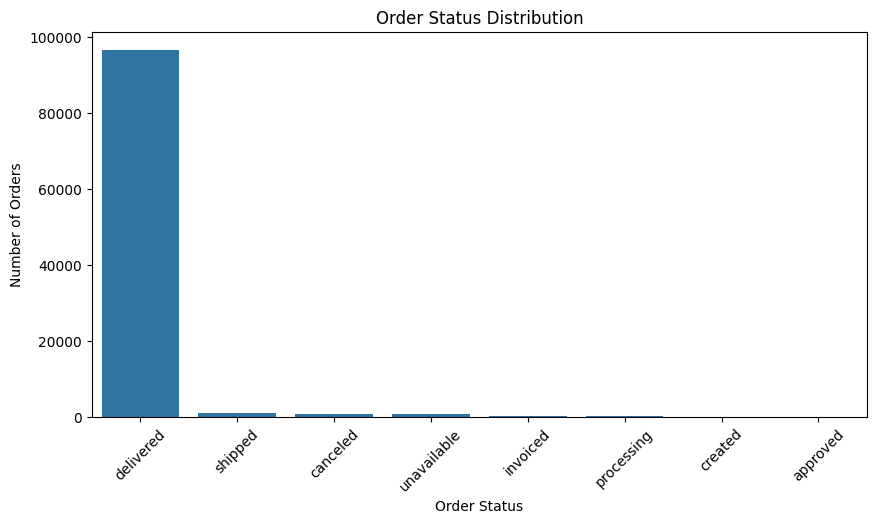

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    x='order_status',
    order=orders['order_status'].value_counts().index
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [ ]:
orders['order_month'] = (
    orders['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

monthly_orders = (
    orders.groupby('order_month')
    .size()
    .reset_index(name='order_count')
)

monthly_orders.head()

,order_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


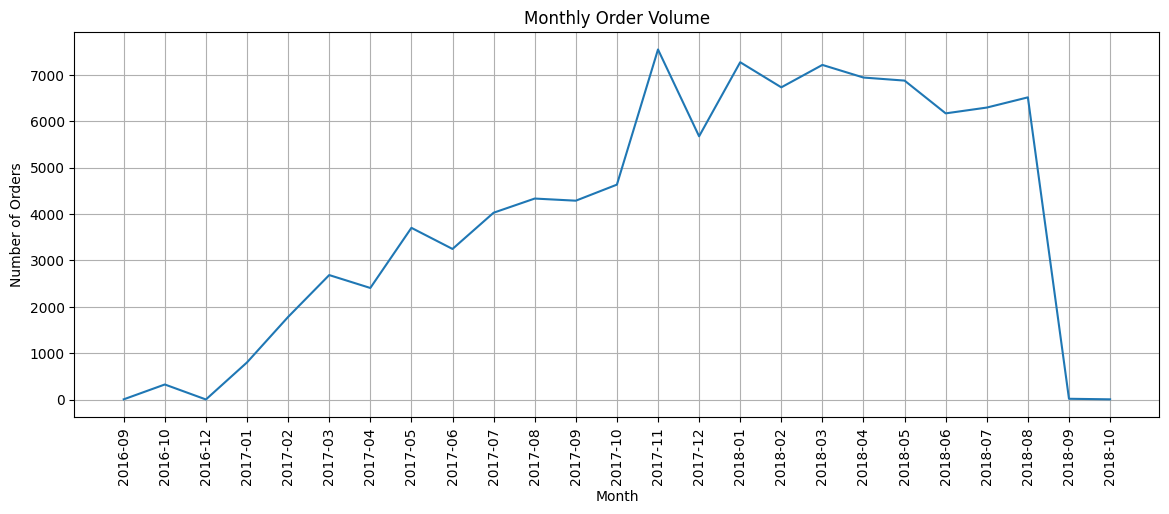

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_orders['order_month'],
    monthly_orders['order_count']
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [ ]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

In [ ]:
delivered = orders[
    orders['order_status'] == 'delivered'
].copy()

print("Delivered orders:", len(delivered))

Delivered orders: 96478


In [ ]:
delivered['delivery_status'] = np.where(
    delivered['delivery_delay_days'] > 0,
    'Late',
    'On Time / Early'
)

print(delivered['delivery_status'].value_counts())

delivery_status
On Time / Early    88652
Late                7826
Name: count, dtype: int64


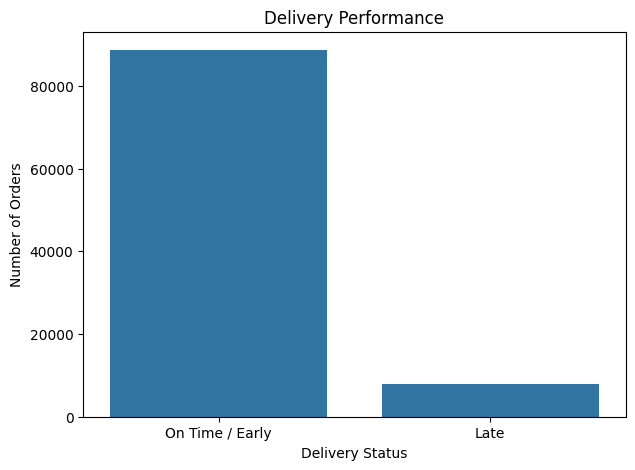

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=delivered,
    x='delivery_status'
)

plt.title('Delivery Performance')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')

plt.show()

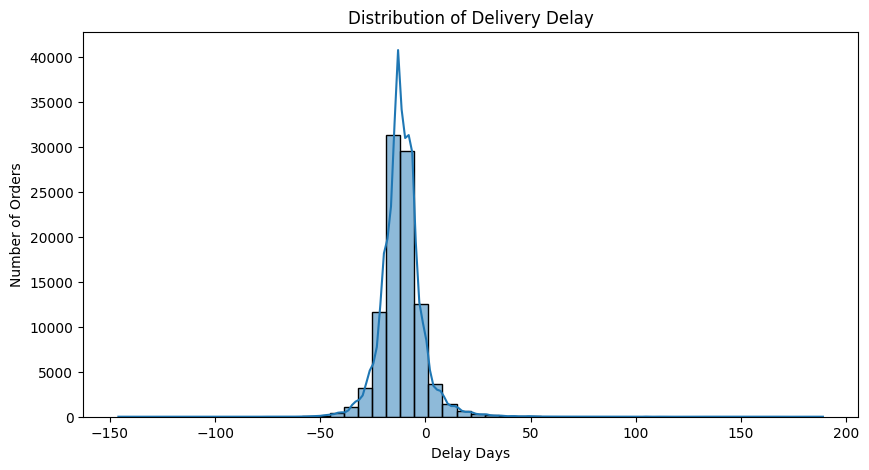

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    delivered['delivery_delay_days'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Delivery Delay')
plt.xlabel('Delay Days')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
item_summary = items.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    product_count=('product_id', 'nunique'),
    seller_count=('seller_id', 'nunique')
).reset_index()

print(item_summary.shape)
item_summary.head()

(98666, 6)


,order_id,total_price,total_freight,item_count,product_count,seller_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,1


In [ ]:
payment_summary = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    payment_count=('payment_sequential', 'count')
).reset_index()

payment_type = (
    payments.groupby('order_id')['payment_type']
    .first()
    .reset_index()
)

payment_summary = payment_summary.merge(
    payment_type,
    on='order_id',
    how='left'
)

print(payment_summary.shape)
payment_summary.head()

(99440, 5)


,order_id,total_payment_value,max_installments,payment_count,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [ ]:
review_summary = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    review_count=('review_id', 'count')
).reset_index()

print(review_summary.shape)
review_summary.head()

(99441, 3)


,order_id,review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [ ]:
products_category = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

print(products_category.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']


In [ ]:
items_category = items.merge(
    products_category[
        ['product_id', 'product_category_name', 'product_category_name_english']
    ],
    on='product_id',
    how='left'
)

items_category.head()

,order_id,order_item_id,product_id,seller_id,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,ferramentas_jardim,garden_tools


In [ ]:
category_summary = (
    items_category.groupby('order_id')
    .agg(
        categories=('product_category_name_english',
                     lambda x: ', '.join(x.dropna().astype(str).unique()))
    )
    .reset_index()
)

category_summary.head()

,order_id,categories
0,00010242fe8c5a6d1ba2dd792cb16214,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,pet_shop
2,000229ec398224ef6ca0657da4fc703e,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools


In [ ]:
master = orders.copy()

master = master.merge(
    customers,
    on='customer_id',
    how='left'
)

master = master.merge(
    item_summary,
    on='order_id',
    how='left'
)

master = master.merge(
    payment_summary,
    on='order_id',
    how='left'
)

master = master.merge(
    review_summary,
    on='order_id',
    how='left'
)

master = master.merge(
    category_summary,
    on='order_id',
    how='left'
)

In [ ]:
print("Master Dataset Shape:", master.shape)

print("\nColumns:")
print(master.columns.tolist())

display(master.head())

Master Dataset Shape: (99441, 28)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_price', 'total_freight', 'item_count', 'product_count', 'seller_count', 'total_payment_value', 'max_installments', 'payment_count', 'payment_type', 'review_score', 'review_count', 'categories']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,delivery_days,...,item_count,product_count,seller_count,total_payment_value,max_installments,payment_count,payment_type,review_score,review_count,categories
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,8.436574,...,1.0,1.0,1.0,38.71,1.0,3.0,credit_card,4.0,1,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,13.782037,...,1.0,1.0,1.0,141.46,1.0,1.0,boleto,4.0,1,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,9.394213,...,1.0,1.0,1.0,179.12,3.0,1.0,credit_card,5.0,1,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,13.208750,...,1.0,1.0,1.0,72.20,1.0,1.0,credit_card,5.0,1,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2.873877,...,1.0,1.0,1.0,28.62,1.0,1.0,credit_card,5.0,1,stationery


In [ ]:
print("Total Revenue:", master['total_price'].sum())
print("Total Payment:", master['total_payment_value'].sum())
print("Average Order Value:", master['total_price'].mean())

Total Revenue: 13591643.700000001
Total Payment: 16008872.120000001
Average Order Value: 137.75407637889447


In [ ]:
category_performance = (
    items_category
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        avg_freight=('freight_value', 'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

category_performance.head(10)

,product_category_name_english,orders,revenue,avg_price,avg_freight
43,health_beauty,8836,1258681.34,130.163531,18.879703
70,watches_gifts,5624,1205005.68,201.135984,16.781160
7,bed_bath_table,9417,1036988.68,93.296327,18.415928
65,sports_leisure,7720,988048.97,114.344285,19.512500
15,computers_accessories,6689,911954.32,116.513903,18.821781
39,furniture_decor,6449,729762.49,87.564494,20.728258
20,cool_stuff,3632,635290.85,167.357969,22.138857
49,housewares,5884,632248.66,90.788148,20.986374
5,auto,3897,592720.11,139.957523,21.880569
42,garden_tools,3518,485256.46,111.630196,22.765758


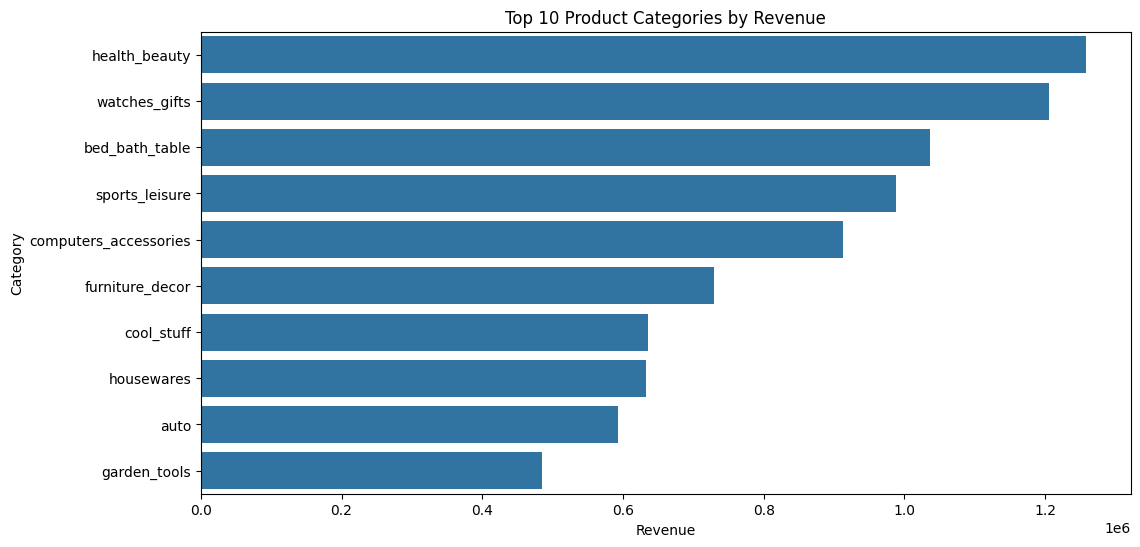

In [ ]:
top_categories = category_performance.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_categories,
    x='revenue',
    y='product_category_name_english'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')

plt.show()

In [ ]:
delivered = master[
    master['order_status'] == 'delivered'
].copy()

print("Delivered Orders:", delivered.shape[0])

Delivered Orders: 96478


In [ ]:
delivered['delivery_status'] = np.where(
    delivered['delivery_delay_days'] > 0,
    'Late',
    'On Time / Early'
)

print(delivered['delivery_status'].value_counts())

delivery_status
On Time / Early    88652
Late                7826
Name: count, dtype: int64


In [ ]:
delivery_review = (
    delivered
    .groupby('delivery_status')
    .agg(
        orders=('order_id', 'nunique'),
        avg_review_score=('review_score', 'mean'),
        avg_delay_days=('delivery_delay_days', 'mean')
    )
    .reset_index()
)

display(delivery_review)

,delivery_status,orders,avg_review_score,avg_delay_days
0,Late,7826,2.546384,9.551776
1,On Time / Early,88652,4.283650,-13.008280


In [ ]:
delivered['delay_bucket'] = pd.cut(
    delivered['delivery_delay_days'],
    bins=[-1000, -1, 0, 3, 7, 14, 1000],
    labels=[
        'Early',
        'On Time',
        '1-3 Days Late',
        '4-7 Days Late',
        '8-14 Days Late',
        '15+ Days Late'
    ]
)

In [ ]:
delay_review = (
    delivered
    .groupby('delay_bucket', observed=True)
    .agg(
        orders=('order_id', 'nunique'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

display(delay_review)

,delay_bucket,orders,avg_review
0,Early,87182,4.285932
1,On Time,1462,4.146375
2,1-3 Days Late,2662,3.749624
3,4-7 Days Late,1819,2.297691
4,8-14 Days Late,1790,1.739665
5,15+ Days Late,1555,1.706109


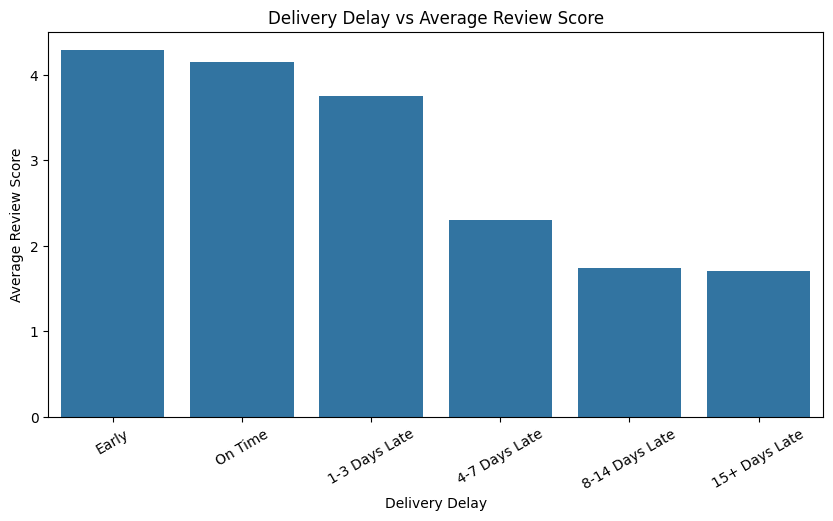

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=delay_review,
    x='delay_bucket',
    y='avg_review'
)

plt.title('Delivery Delay vs Average Review Score')
plt.xlabel('Delivery Delay')
plt.ylabel('Average Review Score')
plt.xticks(rotation=30)

plt.show()

In [ ]:
delivered['low_rating'] = delivered['review_score'] <= 2

print(
    delivered['low_rating']
    .value_counts()
)

low_rating
False    83823
True     12655
Name: count, dtype: int64


In [ ]:
low_rating_analysis = (
    delivered
    .groupby('low_rating')
    .agg(
        orders=('order_id', 'nunique'),
        avg_delay=('delivery_delay_days', 'mean'),
        avg_freight=('total_freight', 'mean'),
        avg_order_value=('total_price', 'mean')
    )
    .reset_index()
)

display(low_rating_analysis)

,low_rating,orders,avg_delay,avg_freight,avg_order_value
0,False,83823,-12.204149,22.036959,133.459076
1,True,12655,-4.382081,27.741734,160.771076


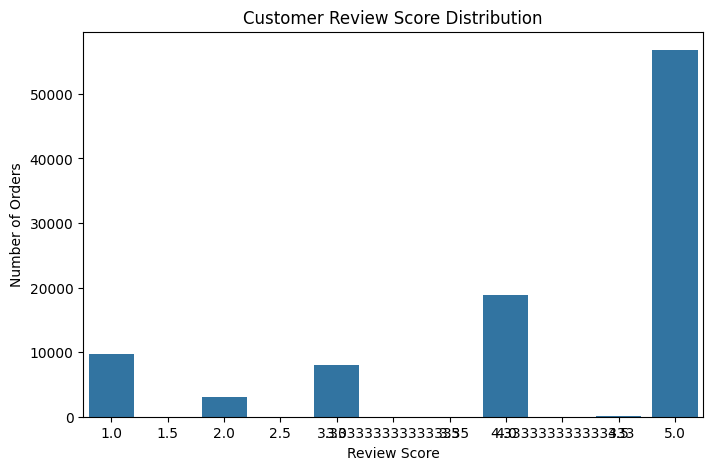

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=delivered,
    x='review_score'
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
review_delay = (
    delivered
    .groupby('review_score')
    .agg(
        avg_delay=('delivery_delay_days', 'mean'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

display(review_delay)

,review_score,avg_delay,orders
0,1.000000,-3.316640,9659
1,1.500000,-5.342746,8
2,2.000000,-7.823292,2988
3,2.500000,-7.033640,33
4,3.000000,-10.075250,8007
5,3.333333,-13.091065,1
6,3.500000,-14.688325,24
7,4.000000,-11.673665,18918
8,4.333333,-10.287153,1
9,4.500000,-12.320761,54


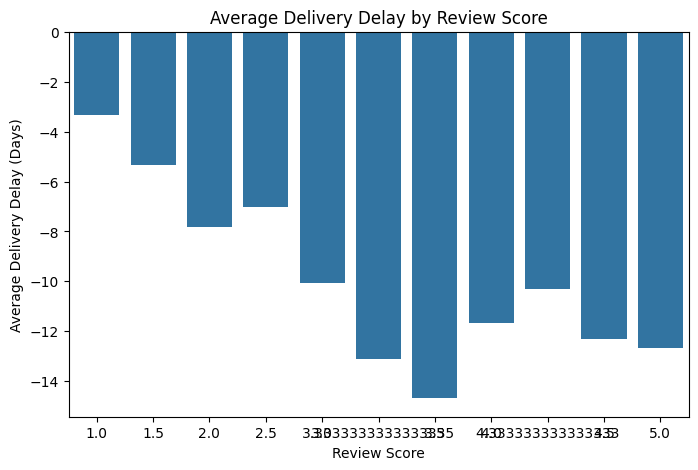

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_delay,
    x='review_score',
    y='avg_delay'
)

plt.title('Average Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (Days)')

plt.show()

In [ ]:
state_analysis = (
    delivered
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        avg_freight=('total_freight', 'mean'),
        avg_delay=('delivery_delay_days', 'mean'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

state_analysis = state_analysis.sort_values(
    'orders',
    ascending=False
)

display(state_analysis.head(15))

,customer_state,orders,avg_freight,avg_delay,avg_review
25,SP,40501,17.334633,-10.380350,4.234854
18,RJ,12350,23.947404,-11.054735,3.946748
10,MG,11354,23.463963,-12.539234,4.179584
22,RS,5345,24.803615,-13.208489,4.180730
17,PR,4923,23.490817,-12.619678,4.228519
23,SC,3546,24.849309,-10.801736,4.116751
4,BA,3256,29.961201,-10.099073,3.909859
6,DF,2080,23.858144,-11.339525,4.127404
7,ES,1995,24.568662,-9.797109,4.048120
8,GO,1957,26.252248,-11.483577,4.089423


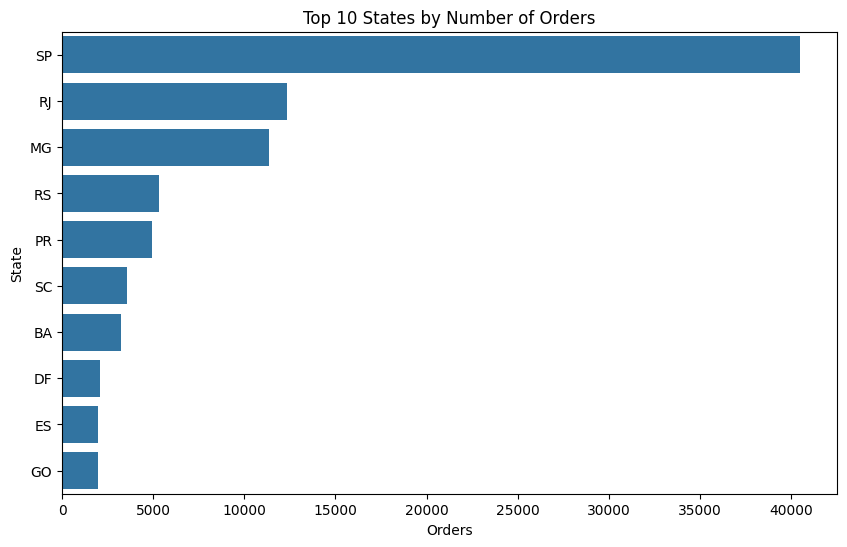

In [ ]:
top_states = state_analysis.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states,
    x='orders',
    y='customer_state'
)

plt.title('Top 10 States by Number of Orders')
plt.xlabel('Orders')
plt.ylabel('State')

plt.show()

In [ ]:
seller_performance = (
    items.groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        products_sold=('product_id', 'nunique'),
        total_sales=('price', 'sum'),
        total_freight=('freight_value', 'sum')
    )
    .reset_index()
)

seller_performance = seller_performance.sort_values(
    'orders',
    ascending=False
)

display(seller_performance.head(10))

,seller_id,orders,products_sold,total_sales,total_freight
1235,6560211a19b47992c3666cc44a7e94c0,1854,256,123304.83,27960.94
881,4a3ca9315b744ce9f8e9374361493884,1806,399,200472.92,35067.04
2481,cc419e0650a3c5ba77189a1882b7556a,1706,37,104288.42,25668.99
368,1f50f920176fa81dab994f9023523100,1404,23,106939.21,35165.77
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,222,160236.57,24955.75
1824,955fee9216a65b617aa5c0531780ce60,1287,104,135171.70,25430.98
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,149,141745.53,20902.85
2836,ea8482cd71df3c1969d7b9473ff13abc,1146,220,37177.52,17544.77
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,95,229472.63,20168.07
731,3d871de0142ce09b7081e2b9d1733cb1,1080,202,94914.20,22433.51


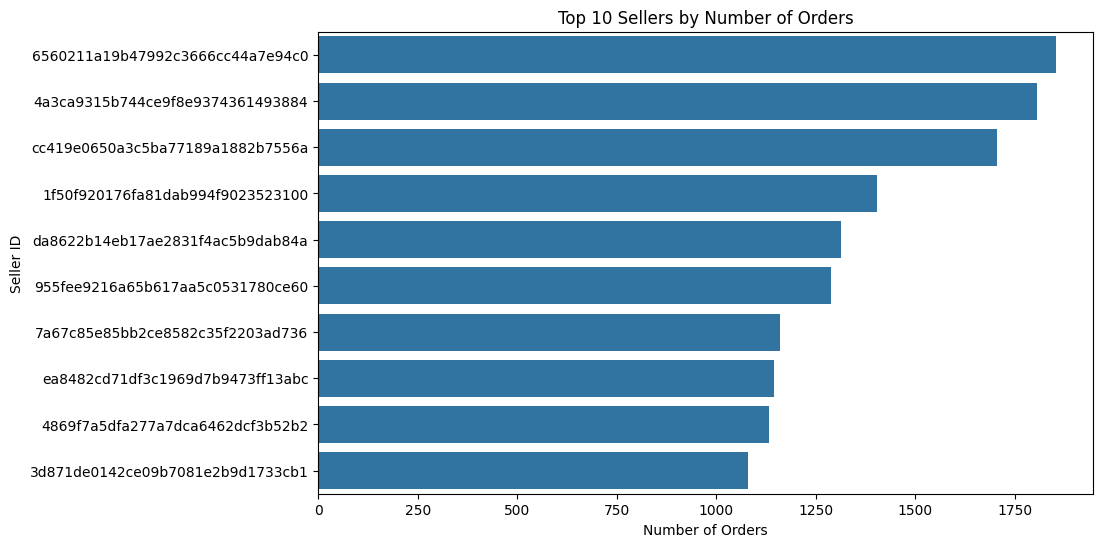

In [ ]:
top_sellers = seller_performance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sellers,
    x='orders',
    y='seller_id'
)

plt.title('Top 10 Sellers by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Seller ID')

plt.show()

In [ ]:
payment_analysis = (
    payments.groupby('payment_type')
    .agg(
        orders=('order_id', 'nunique'),
        transactions=('payment_sequential', 'count'),
        total_payment=('payment_value', 'sum'),
        avg_payment=('payment_value', 'mean')
    )
    .reset_index()
    .sort_values('orders', ascending=False)
)

display(payment_analysis)

,payment_type,orders,transactions,total_payment,avg_payment
1,credit_card,76505,76795,12542084.19,163.319021
0,boleto,19784,19784,2869361.27,145.034435
4,voucher,3866,5775,379436.87,65.703354
2,debit_card,1528,1529,217989.79,142.570170
3,not_defined,3,3,0.00,0.000000


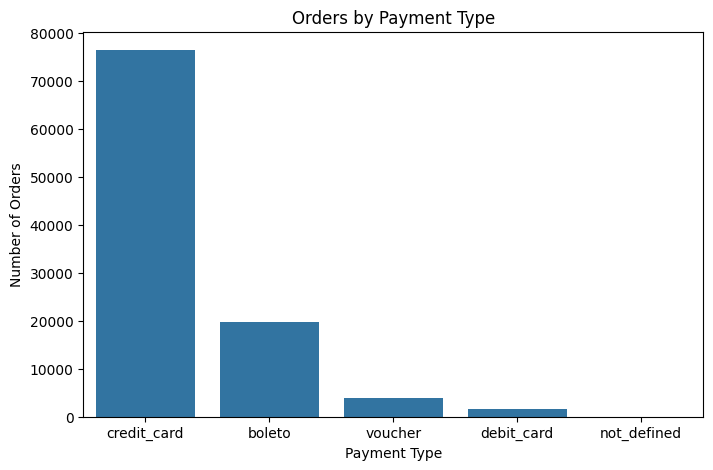

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_analysis,
    x='payment_type',
    y='orders'
)

plt.title('Orders by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')

plt.show()

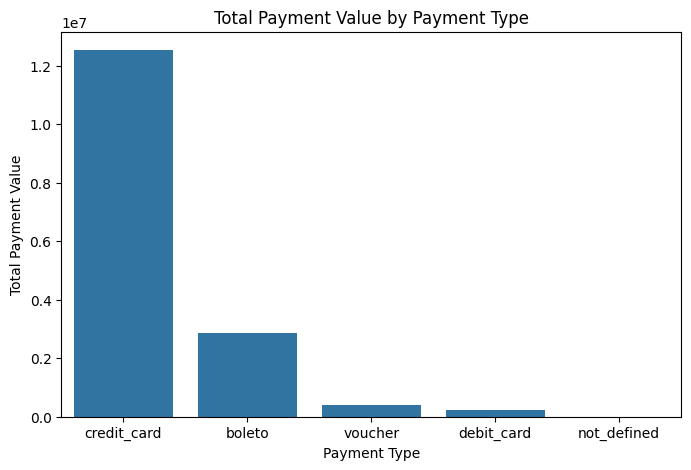

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_analysis,
    x='payment_type',
    y='total_payment'
)

plt.title('Total Payment Value by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Payment Value')

plt.show()

In [ ]:
installment_analysis = (
    payments.groupby('payment_installments')
    .agg(
        orders=('order_id', 'nunique'),
        total_value=('payment_value', 'sum')
    )
    .reset_index()
    .sort_values('payment_installments')
)

display(installment_analysis.head(20))

,payment_installments,orders,total_value
0,0,2,188.63
1,1,49060,5907233.36
2,2,12389,1579283.03
3,3,10443,1491103.80
4,4,7088,1163907.61
5,5,5234,961174.30
6,6,3916,822611.81
7,7,1623,305157.39
8,8,4253,1313423.34
9,9,644,131015.92


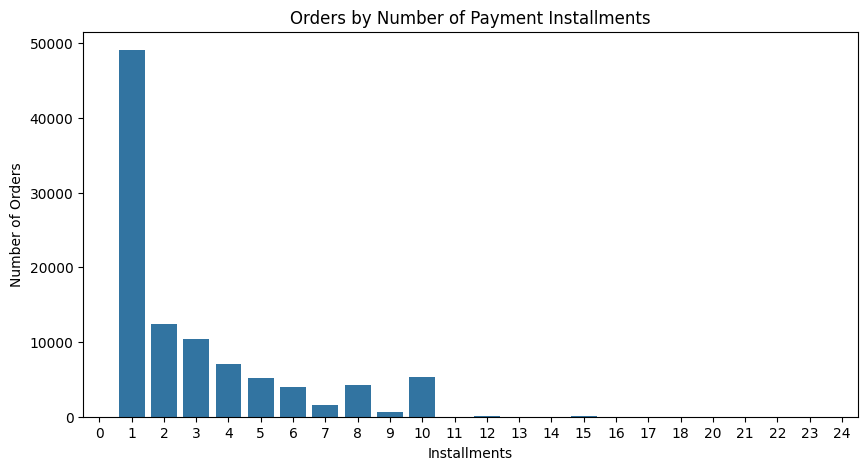

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=installment_analysis,
    x='payment_installments',
    y='orders'
)

plt.title('Orders by Number of Payment Installments')
plt.xlabel('Installments')
plt.ylabel('Number of Orders')

plt.show()

In [ ]:
category_review = (
    items_category
    .merge(
        reviews[['order_id', 'review_score']],
        on='order_id',
        how='left'
    )
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('price', 'sum'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

In [ ]:
category_review_filtered = category_review[
    category_review['orders'] >= 100
].sort_values(
    'avg_review',
    ascending=True
)

display(category_review_filtered.head(10))

,product_category_name_english,orders,revenue,avg_review
57,office_furniture,1273,275224.49,3.484421
30,fashion_male_clothing,112,10797.82,3.621212
34,fixed_telephony,217,59622.99,3.671698
4,audio,350,50738.40,3.808219
47,home_confort,397,58828.74,3.826087
19,construction_tools_safety,167,40544.52,3.829897
7,bed_bath_table,9417,1051085.50,3.871185
40,furniture_living_room,422,69427.26,3.885602
39,furniture_decor,6449,736682.46,3.887357
12,christmas_supplies,128,8800.82,3.908497


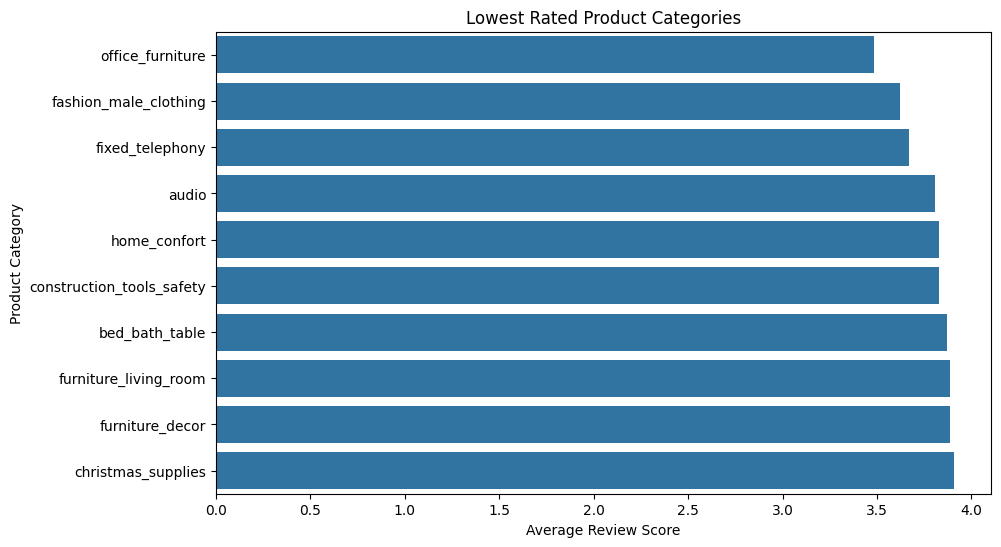

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_review_filtered.head(10),
    x='avg_review',
    y='product_category_name_english'
)

plt.title('Lowest Rated Product Categories')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')

plt.show()

In [ ]:
root_cause = delivered.copy()

root_cause['rating_group'] = np.where(
    root_cause['review_score'] <= 2,
    'Low Rating (1-2)',
    'Higher Rating (3-5)'
)

root_cause_analysis = (
    root_cause
    .groupby('rating_group')
    .agg(
        orders=('order_id', 'nunique'),
        avg_delay=('delivery_delay_days', 'mean'),
        avg_freight=('total_freight', 'mean'),
        avg_order_value=('total_price', 'mean'),
        avg_items=('item_count', 'mean')
    )
    .reset_index()
)

display(root_cause_analysis)

,rating_group,orders,avg_delay,avg_freight,avg_order_value,avg_items
0,Higher Rating (3-5),83823,-12.204149,22.036959,133.459076,1.115672
1,Low Rating (1-2),12655,-4.382081,27.741734,160.771076,1.317898


In [ ]:
customer_orders = (
    master.groupby('customer_unique_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_spent=('total_payment_value', 'sum'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

customer_orders['customer_type'] = np.where(
    customer_orders['total_orders'] > 1,
    'Repeat Customer',
    'One-time Customer'
)

display(customer_orders['customer_type'].value_counts())

,count
customer_type,
One-time Customer,93099
Repeat Customer,2997


In [ ]:
customer_type_summary = (
    customer_orders
    .groupby('customer_type')
    .agg(
        customers=('customer_unique_id', 'nunique'),
        avg_orders=('total_orders', 'mean'),
        avg_spent=('total_spent', 'mean'),
        avg_review=('avg_review', 'mean')
    )
    .reset_index()
)

display(customer_type_summary)

,customer_type,customers,avg_orders,avg_spent,avg_review
0,One-time Customer,93099,1.000000,161.815373,4.068594
1,Repeat Customer,2997,2.116116,314.989226,4.098008


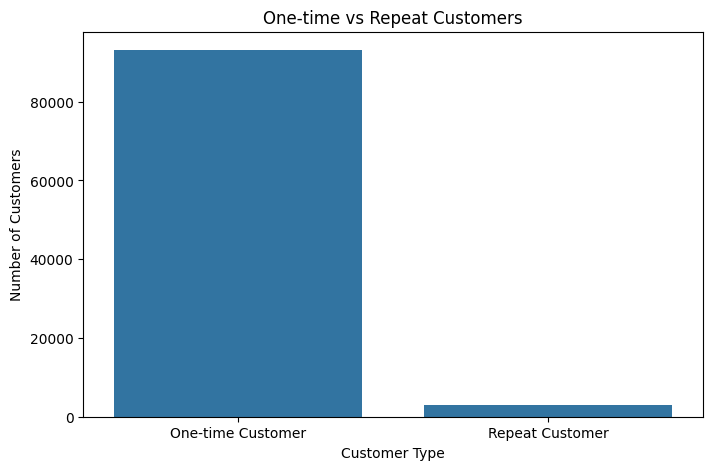

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_type_summary,
    x='customer_type',
    y='customers'
)

plt.title('One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.show()

In [ ]:
total_orders = master['order_id'].nunique()

delivered_orders = (
    master[master['order_status'] == 'delivered']['order_id']
    .nunique()
)

total_revenue = master['total_price'].sum()

avg_order_value = master['total_price'].mean()

avg_review = master['review_score'].mean()

late_percentage = (
    delivered['delivery_status'].eq('Late').mean() * 100
)

print("========== OLIST KPI SUMMARY ==========")
print("Total Orders       :", total_orders)
print("Delivered Orders   :", delivered_orders)
print("Total Revenue      :", round(total_revenue, 2))
print("Average Order Value:", round(avg_order_value, 2))
print("Average Review     :", round(avg_review, 2))
print("Late Delivery %    :", round(late_percentage, 2), "%")

========== OLIST KPI SUMMARY ==========
Total Orders       : 99441
Delivered Orders   : 96478
Total Revenue      : 13591643.7
Average Order Value: 137.75
Average Review     : 4.07
Late Delivery %    : 8.11 %


In [ ]:
monthly_performance = (
    master.groupby('order_month')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('total_price', 'sum'),
        avg_review=('review_score', 'mean')
    )
    .reset_index()
)

display(monthly_performance)

,order_month,orders,revenue,avg_review
0,2016-09,4,267.36,1.000000
1,2016-10,324,49507.66,3.520062
2,2016-12,1,10.90,5.000000
3,2017-01,800,120312.87,4.046875
4,2017-02,1780,247303.02,4.003371
5,2017-03,2682,374344.30,4.057979
6,2017-04,2404,359927.23,4.034110
7,2017-05,3700,506071.14,4.123243
8,2017-06,3245,433038.60,4.129892
9,2017-07,4026,498031.48,4.161409


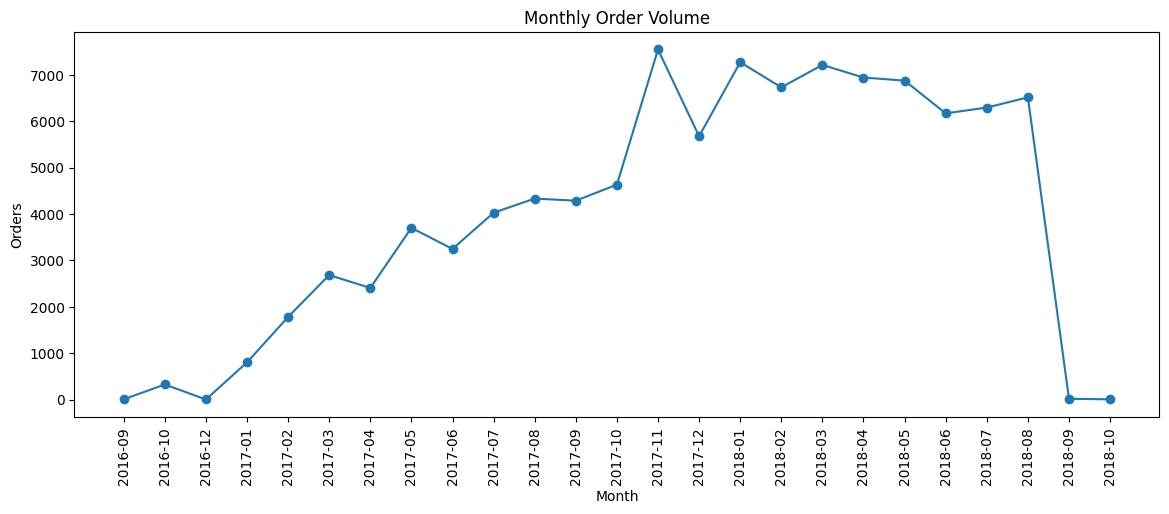

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_performance['order_month'],
    monthly_performance['orders'],
    marker='o'
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=90)

plt.show()

In [ ]:
display(delivery_review)

,delivery_status,orders,avg_review_score,avg_delay_days
0,Late,7826,2.546384,9.551776
1,On Time / Early,88652,4.283650,-13.008280


In [ ]:
display(seller_performance.head(10))

,seller_id,orders,products_sold,total_sales,total_freight
1235,6560211a19b47992c3666cc44a7e94c0,1854,256,123304.83,27960.94
881,4a3ca9315b744ce9f8e9374361493884,1806,399,200472.92,35067.04
2481,cc419e0650a3c5ba77189a1882b7556a,1706,37,104288.42,25668.99
368,1f50f920176fa81dab994f9023523100,1404,23,106939.21,35165.77
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,222,160236.57,24955.75
1824,955fee9216a65b617aa5c0531780ce60,1287,104,135171.70,25430.98
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,149,141745.53,20902.85
2836,ea8482cd71df3c1969d7b9473ff13abc,1146,220,37177.52,17544.77
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,95,229472.63,20168.07
731,3d871de0142ce09b7081e2b9d1733cb1,1080,202,94914.20,22433.51


In [ ]:
display(
    state_analysis.sort_values(
        'avg_review',
        ascending=True
    ).head(10)
)

,customer_state,orders,avg_freight,avg_delay,avg_review
9,MA,717,42.948633,-8.887844,3.813808
1,AL,397,38.581285,-8.032059,3.831234
13,PA,946,39.696596,-13.386288,3.886892
24,SE,335,40.940119,-9.328641,3.898507
21,RR,41,48.342683,-16.594598,3.902439
4,BA,3256,29.961201,-10.099073,3.909859
5,CE,1279,36.496787,-10.110007,3.935106
18,RJ,12350,23.947404,-11.054735,3.946748
16,PI,476,42.977290,-10.629538,3.978992
7,ES,1995,24.568662,-9.797109,4.048120


In [70]:
display(
    category_performance.head(10)
)

,product_category_name_english,orders,revenue,avg_price,avg_freight
43,health_beauty,8836,1258681.34,130.163531,18.879703
70,watches_gifts,5624,1205005.68,201.135984,16.781160
7,bed_bath_table,9417,1036988.68,93.296327,18.415928
65,sports_leisure,7720,988048.97,114.344285,19.512500
15,computers_accessories,6689,911954.32,116.513903,18.821781
39,furniture_decor,6449,729762.49,87.564494,20.728258
20,cool_stuff,3632,635290.85,167.357969,22.138857
49,housewares,5884,632248.66,90.788148,20.986374
5,auto,3897,592720.11,139.957523,21.880569
42,garden_tools,3518,485256.46,111.630196,22.765758


In [71]:
display(
    category_review_filtered.head(10)
)

,product_category_name_english,orders,revenue,avg_review
57,office_furniture,1273,275224.49,3.484421
30,fashion_male_clothing,112,10797.82,3.621212
34,fixed_telephony,217,59622.99,3.671698
4,audio,350,50738.40,3.808219
47,home_confort,397,58828.74,3.826087
19,construction_tools_safety,167,40544.52,3.829897
7,bed_bath_table,9417,1051085.50,3.871185
40,furniture_living_room,422,69427.26,3.885602
39,furniture_decor,6449,736682.46,3.887357
12,christmas_supplies,128,8800.82,3.908497


In [72]:
display(payment_analysis)

,payment_type,orders,transactions,total_payment,avg_payment
1,credit_card,76505,76795,12542084.19,163.319021
0,boleto,19784,19784,2869361.27,145.034435
4,voucher,3866,5775,379436.87,65.703354
2,debit_card,1528,1529,217989.79,142.570170
3,not_defined,3,3,0.00,0.000000


In [73]:
display(root_cause_analysis)

,rating_group,orders,avg_delay,avg_freight,avg_order_value,avg_items
0,Higher Rating (3-5),83823,-12.204149,22.036959,133.459076,1.115672
1,Low Rating (1-2),12655,-4.382081,27.741734,160.771076,1.317898


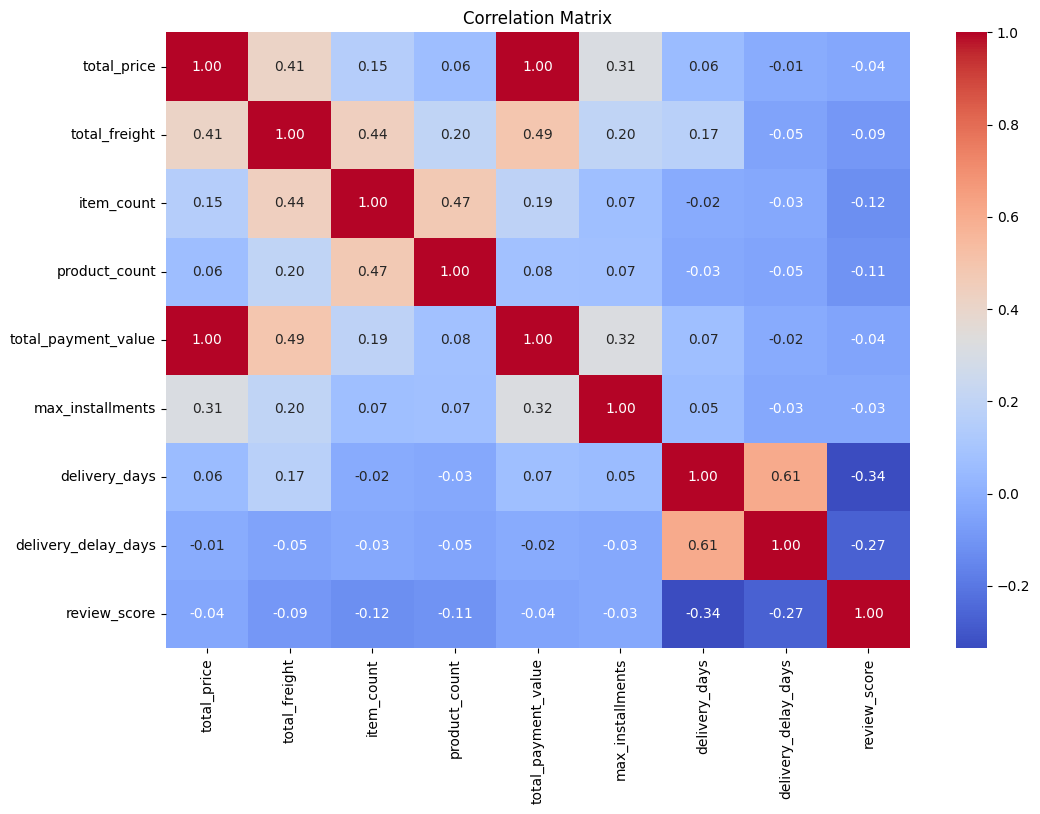

In [74]:
correlation_columns = [
    'total_price',
    'total_freight',
    'item_count',
    'product_count',
    'total_payment_value',
    'max_installments',
    'delivery_days',
    'delivery_delay_days',
    'review_score'
]

corr = delivered[correlation_columns].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [75]:
master.to_excel(
    '/content/olist_master_analysis.xlsx',
    index=False
)

print("Master dataset saved successfully!")

Master dataset saved successfully!


In [76]:
with pd.ExcelWriter('/content/olist_analysis_results.xlsx') as writer:

    monthly_performance.to_excel(
        writer,
        sheet_name='Monthly Performance',
        index=False
    )

    delivery_review.to_excel(
        writer,
        sheet_name='Delivery vs Review',
        index=False
    )

    state_analysis.to_excel(
        writer,
        sheet_name='State Analysis',
        index=False
    )

    seller_performance.to_excel(
        writer,
        sheet_name='Seller Performance',
        index=False
    )

    category_performance.to_excel(
        writer,
        sheet_name='Category Performance',
        index=False
    )

    payment_analysis.to_excel(
        writer,
        sheet_name='Payment Analysis',
        index=False
    )

    root_cause_analysis.to_excel(
        writer,
        sheet_name='Root Cause',
        index=False
    )

print("Analysis results saved!")

Analysis results saved!


In [77]:
from google.colab import files

files.download('/content/olist_master_analysis.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
from google.colab import files

files.download('/content/olist_analysis_results.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
print("========== DELIVERY VS REVIEW ==========")
display(delivery_review)

print("\n========== ROOT CAUSE ANALYSIS ==========")
display(root_cause_analysis)

========== DELIVERY VS REVIEW ==========


,delivery_status,orders,avg_review_score,avg_delay_days
0,Late,7826,2.546384,9.551776
1,On Time / Early,88652,4.283650,-13.008280



========== ROOT CAUSE ANALYSIS ==========


,rating_group,orders,avg_delay,avg_freight,avg_order_value,avg_items
0,Higher Rating (3-5),83823,-12.204149,22.036959,133.459076,1.115672
1,Low Rating (1-2),12655,-4.382081,27.741734,160.771076,1.317898


In [80]:
print("========== STATE ANALYSIS ==========")
print(state_analysis.sort_values('avg_review').head(10).to_string(index=False))

print("\n========== PAYMENT ANALYSIS ==========")
print(payment_analysis.to_string(index=False))

========== STATE ANALYSIS ==========
customer_state  orders  avg_freight  avg_delay  avg_review
            MA     717    42.948633  -8.887844    3.813808
            AL     397    38.581285  -8.032059    3.831234
            PA     946    39.696596 -13.386288    3.886892
            SE     335    40.940119  -9.328641    3.898507
            RR      41    48.342683 -16.594598    3.902439
            BA    3256    29.961201 -10.099073    3.909859
            CE    1279    36.496787 -10.110007    3.935106
            RJ   12350    23.947404 -11.054735    3.946748
            PI     476    42.977290 -10.629538    3.978992
            ES    1995    24.568662  -9.797109    4.048120

========== PAYMENT ANALYSIS ==========
payment_type  orders  transactions  total_payment  avg_payment
 credit_card   76505         76795    12542084.19   163.319021
      boleto   19784         19784     2869361.27   145.034435
     voucher    3866          5775      379436.87    65.703354
  debit_card    1528  

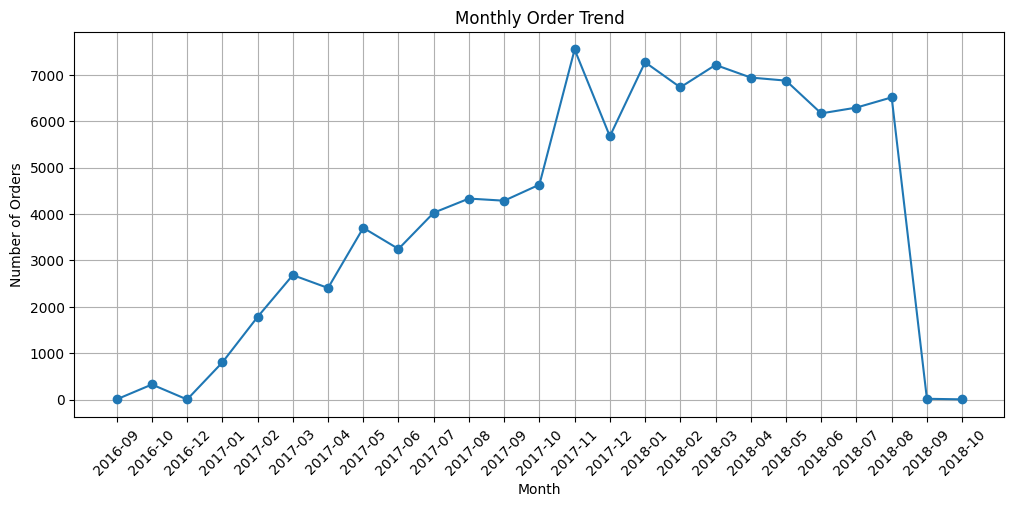

In [81]:
#visualization part charts and graph
plt.figure(figsize=(12,5))

plt.plot(
    monthly_performance['order_month'].astype(str),
    monthly_performance['orders'],
    marker='o'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Order Trend')
plt.grid(True)
plt.show()

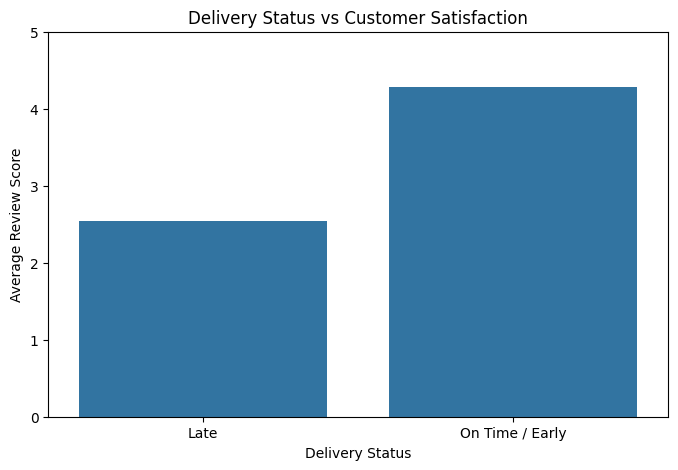

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=delivery_review,
    x='delivery_status',
    y='avg_review_score'
)

plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.title('Delivery Status vs Customer Satisfaction')
plt.ylim(0, 5)
plt.show()

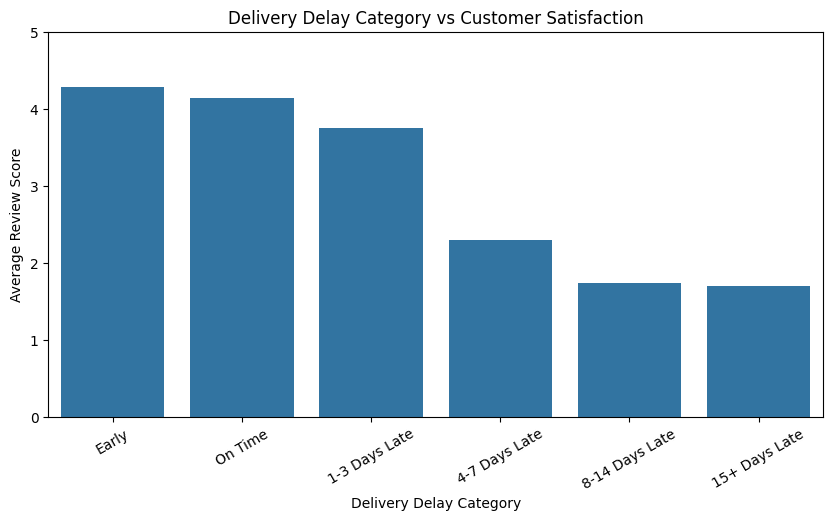

In [84]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=delay_review,
    x='delay_bucket',
    y='avg_review'
)

plt.xlabel('Delivery Delay Category')
plt.ylabel('Average Review Score')
plt.title('Delivery Delay Category vs Customer Satisfaction')
plt.ylim(0, 5)
plt.xticks(rotation=30)
plt.show()

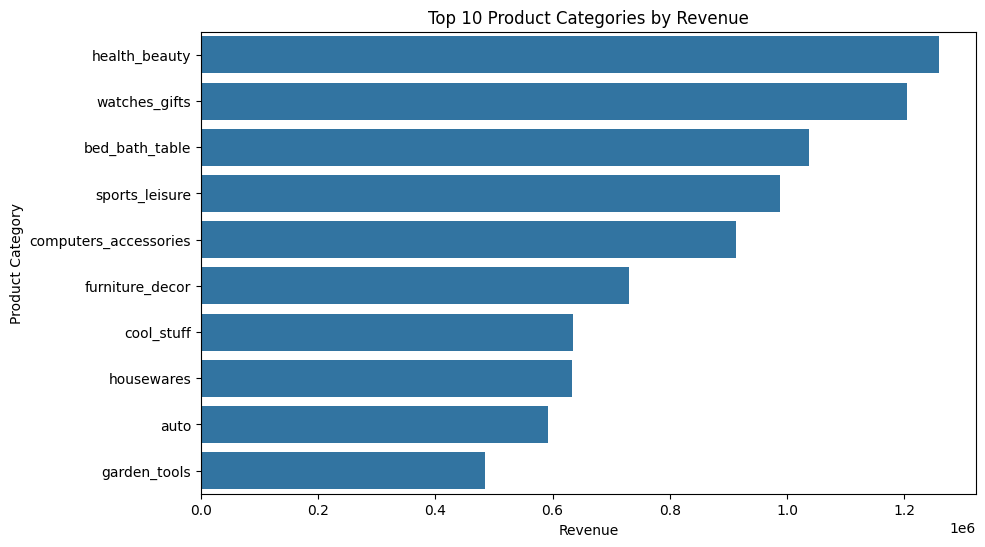

In [85]:
top_categories = (
    category_performance
    .sort_values('revenue', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_categories,
    x='revenue',
    y='product_category_name_english'
)

plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.title('Top 10 Product Categories by Revenue')
plt.show()

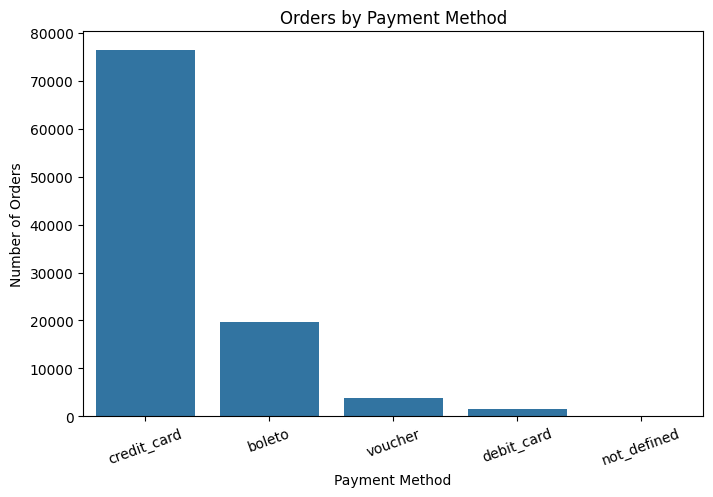

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_analysis,
    x='payment_type',
    y='orders'
)

plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.title('Orders by Payment Method')
plt.xticks(rotation=20)
plt.show()

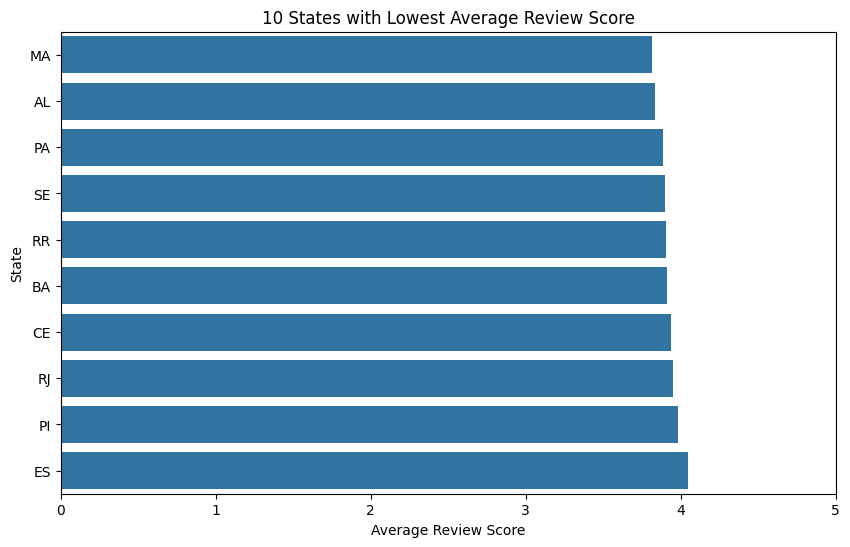

In [87]:
top_states = (
    state_analysis
    .sort_values('avg_review', ascending=True)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_states,
    x='avg_review',
    y='customer_state'
)

plt.xlabel('Average Review Score')
plt.ylabel('State')
plt.title('10 States with Lowest Average Review Score')
plt.xlim(0, 5)
plt.show()

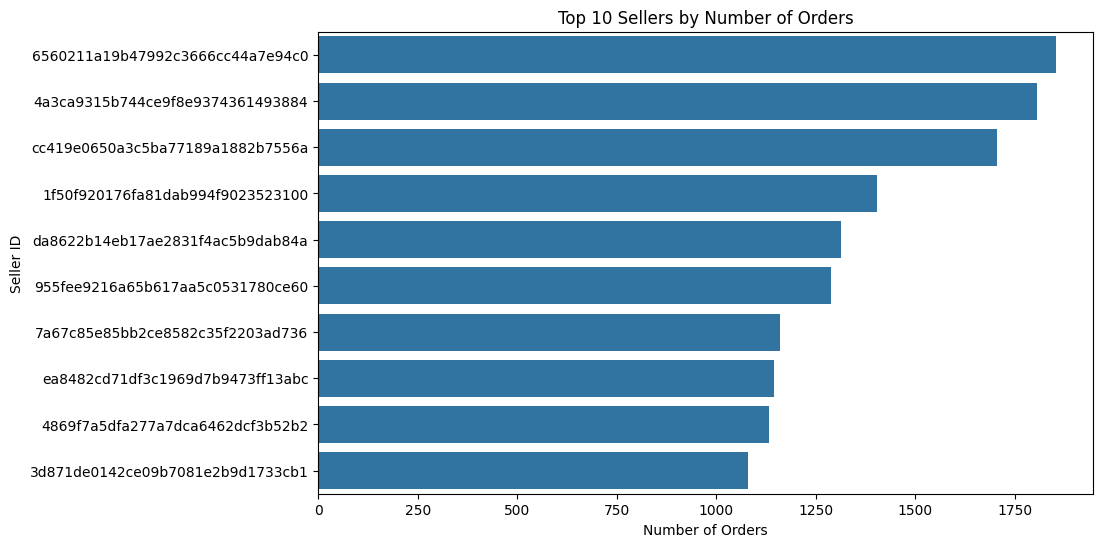

In [88]:
top_sellers = (
    seller_performance
    .sort_values('orders', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_sellers,
    x='orders',
    y='seller_id'
)

plt.xlabel('Number of Orders')
plt.ylabel('Seller ID')
plt.title('Top 10 Sellers by Number of Orders')
plt.show()

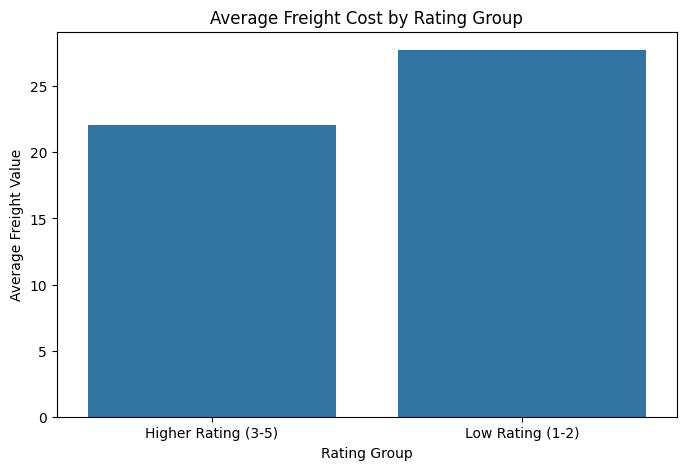

In [89]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=root_cause_analysis,
    x='rating_group',
    y='avg_freight'
)

plt.xlabel('Rating Group')
plt.ylabel('Average Freight Value')
plt.title('Average Freight Cost by Rating Group')
plt.show()

## Key Insights

1. The Olist marketplace showed strong growth in order volume and revenue throughout 2017 and early 2018.

2. November 2017 recorded the highest monthly order volume with 7,544 orders and revenue of approximately 1.01 million.

3. Delivery performance had a strong relationship with customer satisfaction. Late deliveries had an average review score of 2.55, compared with 4.28 for orders delivered on time or early.

4. Low-rated orders had higher average freight costs (27.74) compared with higher-rated orders (22.04), suggesting that shipping cost may be associated with customer dissatisfaction.

5. Customer satisfaction varied across states. MA recorded the lowest average review score among the states analyzed, at approximately 3.81.

6. Credit cards were the dominant payment method, with 76,505 orders, followed by Boleto with 19,784 orders.

7. Delivery delay is an important contributor to low customer satisfaction, but it does not explain every low rating. Other factors such as product quality, seller performance and freight cost should also be considered.


## Business Recommendations

1. Improve logistics and delivery monitoring to reduce late deliveries.

2. Identify high-risk orders and take preventive action before they become delayed.

3. Optimize shipping costs, especially in regions with relatively high freight expenses.

4. Monitor seller performance and identify sellers associated with poor customer experiences.

5. Investigate low-rated orders using product, seller, freight and review information to identify additional causes of dissatisfaction.

## Conclusion

The analysis shows that Olist experienced strong marketplace growth, while customer satisfaction was generally around four stars. The strongest finding is the relationship between delivery performance and customer satisfaction, with late deliveries receiving substantially lower ratings. Geographic differences, freight costs, seller performance and payment behavior also provide useful insights for improving marketplace operations and customer experience.
